In [1]:
import numpy as np

def read_poscar(filename="relaxed-POSCAR"):
    with open(filename, "r") as f:
        lines = f.readlines()

    scale = float(lines[1].strip())
    a_vec = [float(x) for x in lines[2].split()]
    b_vec = [float(x) for x in lines[3].split()]
    c_vec = [float(x) for x in lines[4].split()]
    species_line = lines[5].strip()
    counts_line  = lines[6].strip()
    coord_type   = lines[7].strip()
    atom_coords  = [lines[i].strip() for i in range(8, len(lines)) if lines[i].strip()]

    return scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords

strain_list = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18]

scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords = read_poscar()

for i in strain_list:
    factor = 1 + i / 100

    # Only scale the in-plane (x, y) components; leave z untouched
    def strain_vec(v):
        return [v[0] , v[1] * factor, v[2]]

    a_s = strain_vec(a_vec)
    b_s = strain_vec(b_vec)
    c_s = strain_vec(c_vec)

    filename = f"POSCAR-{i}"
    content = (
        f"Buckled BiAs strained {i}%\n"
        f"   {scale:.14f}\n"
        f"\t{a_s[0]:.15f}\t{a_s[1]:.15f}\t{a_s[2]:.15f}\n"
        f"\t{b_s[0]:.15f}\t{b_s[1]:.15f}\t{b_s[2]:.15f}\n"
        f"\t{c_s[0]:.15f}\t{c_s[1]:.15f}\t{c_s[2]:.15f}\n"
        f"   {species_line}\n"
        f"    {counts_line}\n"
        f"{coord_type}\n"
    )
    for coord in atom_coords:
        content += f"\t{coord}\n"

    with open(filename, "w") as f:
        f.write(content)

    print(f"Written: {filename}")

Written: POSCAR-2
Written: POSCAR-4
Written: POSCAR-6
Written: POSCAR-8
Written: POSCAR-10
Written: POSCAR-11
Written: POSCAR-12
Written: POSCAR-13
Written: POSCAR-14
Written: POSCAR-16
Written: POSCAR-18


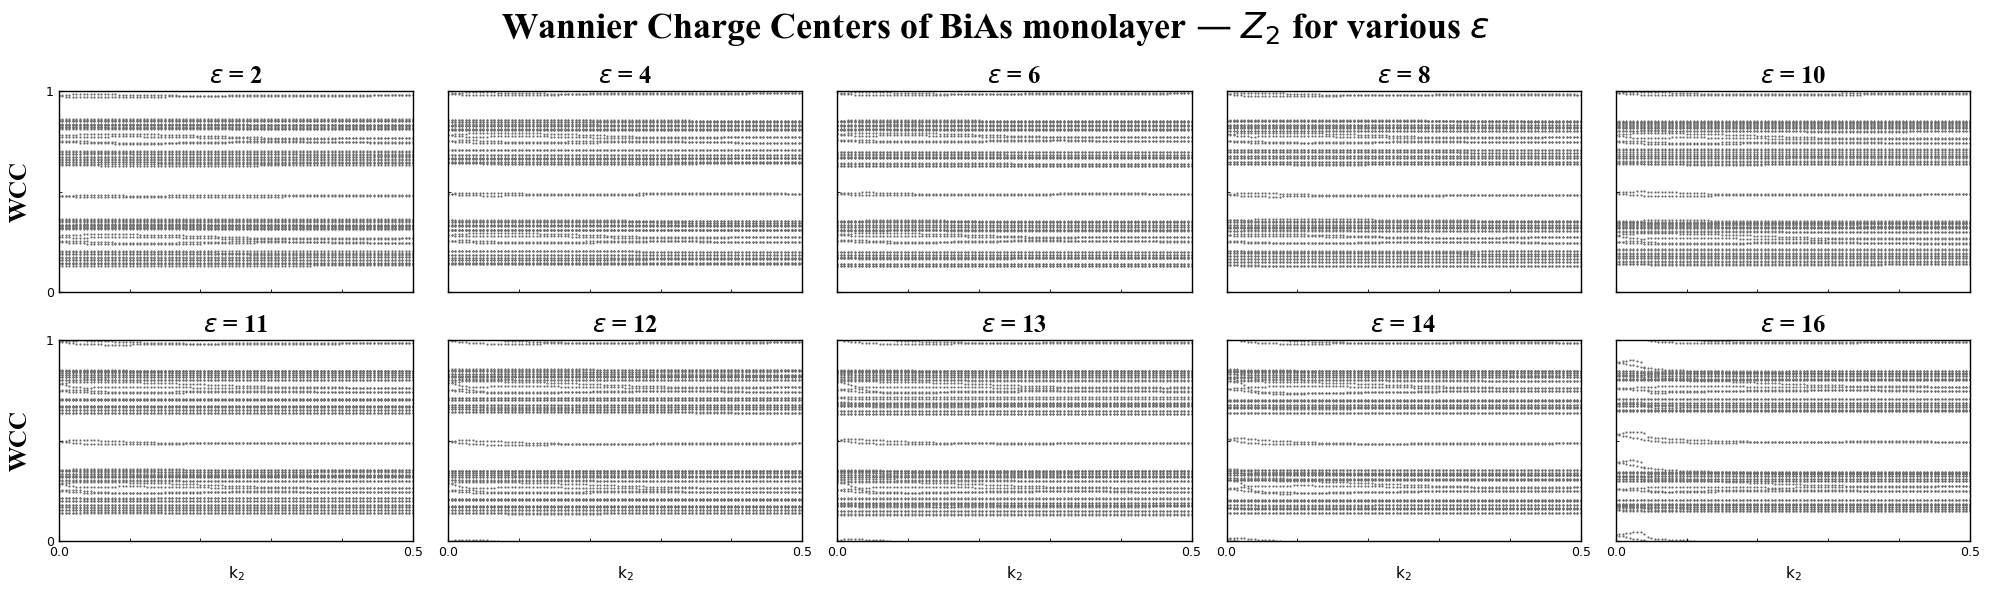

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = '#696969'
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, file_indices):
    try:
        data = np.loadtxt(f"{idx}-wanniercenter3D_Z2_6.dat")
        ax.scatter(data[:, 0] / 2, data[:, 1],
                   s=2.5, color=LCOLOR, marker='o', linewidths=0)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'e{idx} not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', which='both', direction='in', labelsize=9)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
    ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

    ax.set_title(rf'$\epsilon$ = {idx}', fontname="Times New Roman",fontweight="bold",fontsize=18)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('WCC', rotation=90, fontname="Times New Roman",fontweight="bold", fontsize=18, labelpad=10)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(r'k$_2$', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle(r'Wannier Charge Centers of BiAs monolayer — $Z_2$ for various $\epsilon$', fontname="Times New Roman",fontweight="bold",fontsize=26)
plt.tight_layout()
plt.savefig("wannier_centers_comparison.png", dpi=300)
plt.show()

[0.0, 0.452, 1.342, 2.232, 2.999]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.329, 2.206, 2.958]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.317, 2.182, 2.92]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.305, 2.159, 2.883]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.294, 2.136, 2.848]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.289, 2.126, 2.83]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.283, 2.115, 2.814]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.278, 2.105, 2.797]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.273, 2.095, 2.781]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.452, 1.263, 2.075, 2.749]
Number of bands below Fermi level in DFT data: 60


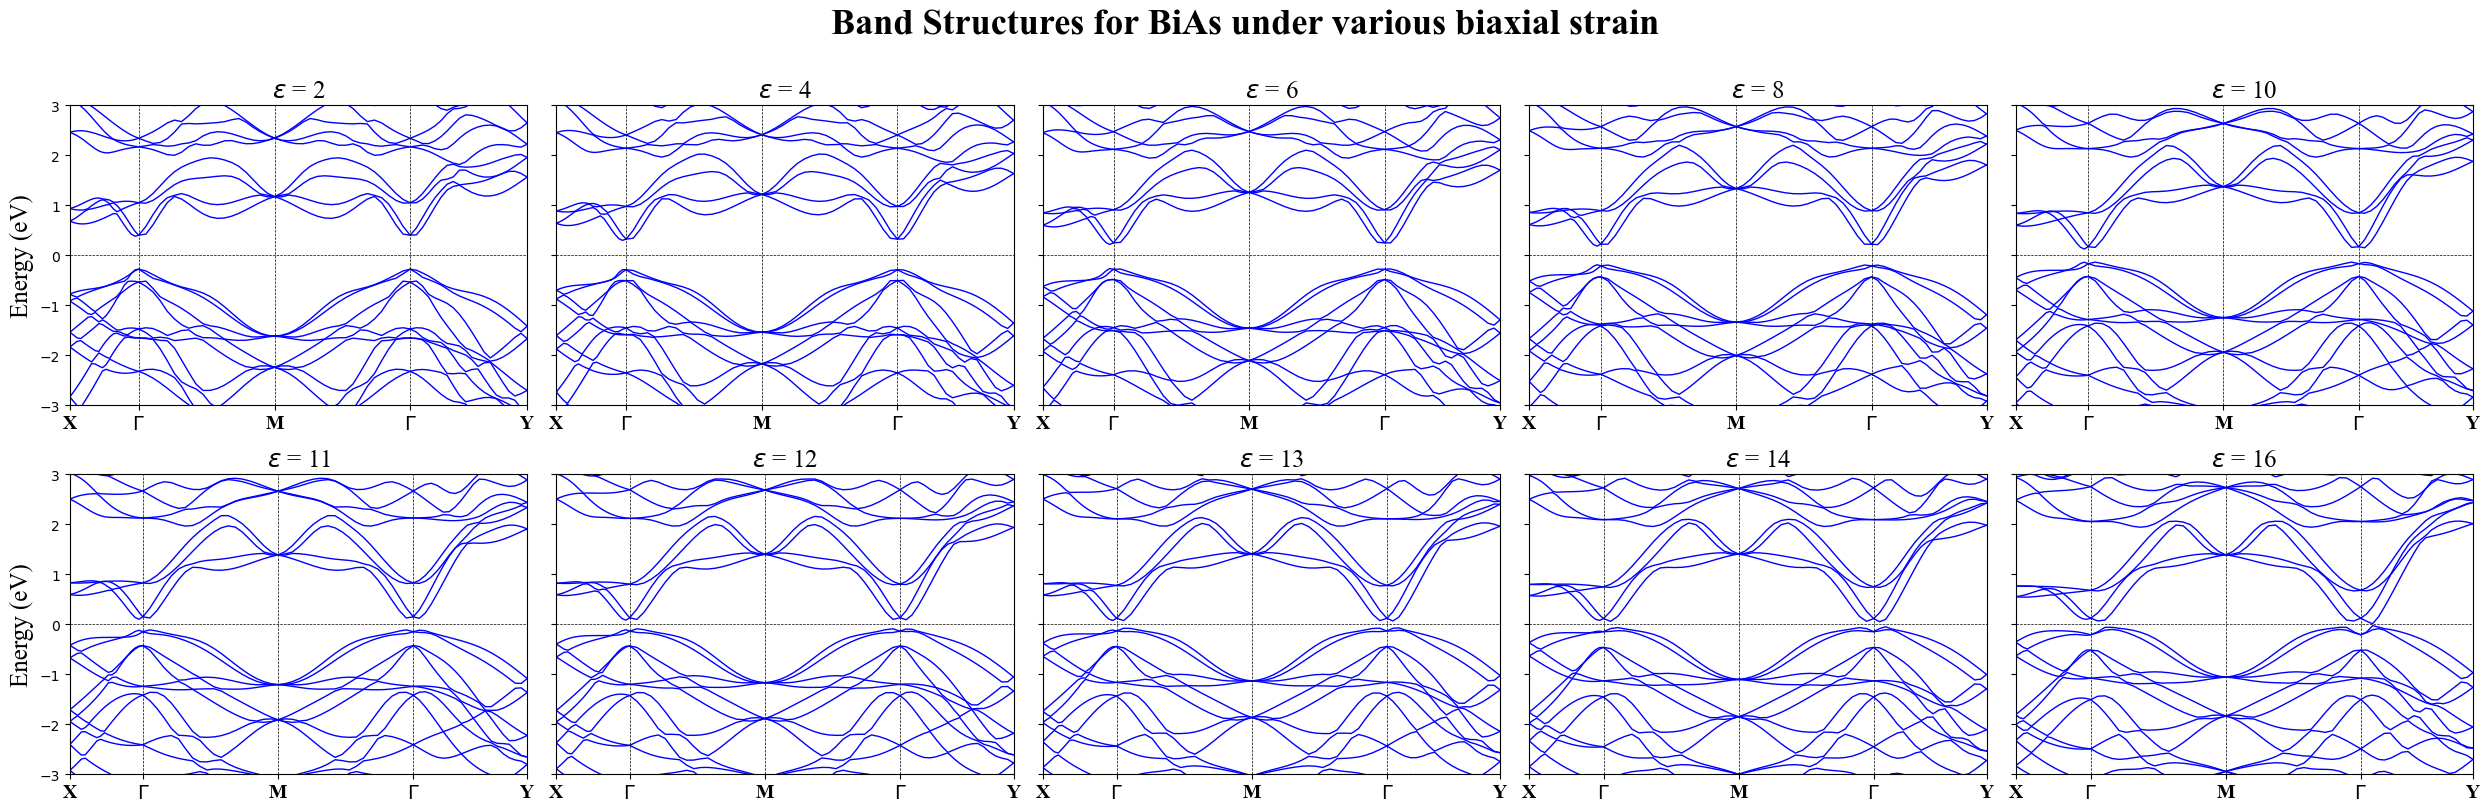

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]
high_symmetry_points = [0, 0.780, 1.456, 1.846, 2.626]
high_sym_labels = ['X', r'$\Gamma$', 'M',  r'$\Gamma$', 'Y']

# --- Load all datasets ---
datasets = {i: np.loadtxt(f"{i}-REFORMATTED_BAND.dat") for i in file_indices}

# --- Layout: 4 cols, enough rows to fit all ---
n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                          sharey=True)
axes = axes.flatten()

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

for ax, (idx, data) in zip(axes, datasets.items()):
    k = data[:, 0]
    bands = data[:, 1:]
    high_sym_points = read_klabels(f"labels/{idx}-KLABELS")
    print(high_sym_points)
    for i in range(bands.shape[1]):
        ax.plot(k, bands[:, i], color='blue', linewidth=1, label='DFT' if i == 0 else "")

    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlim(k.min(), k.max())

    for i in range(len(high_sym_points)):
        ax.axvline(high_sym_points[i],lw=0.5,ls="--",color='black')

    ax.set_ylim(-3, 3)
    ax.set_xticks(high_sym_points)
    ax.set_xticklabels(high_sym_labels, fontsize=14, fontname="Times New Roman",fontweight="bold")
    ax.set_title(rf'$\epsilon$ = {idx}',fontsize=18, fontname="Times New Roman")
    num_bands_below_fermi = np.sum(bands[0, :] < 0) 

    print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Energy (eV)', fontsize=18, fontname="Times New Roman")

# Hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Band Structures for BiAs under various biaxial strain', fontsize=26, fontname="Times New Roman",fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()